## Analyse 1: Häufigste Parking Violation Typen FY2023–FY2025
Welche Violation-Typen kommen am häufigsten vor und wie verändern sie sich über die Jahre?

In [31]:
import pyspark.sql.functions as f
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
from pyspark.sql import SparkSession

# Alte (evtl. tote) Session sauber wegräumen
try:
    SparkSession.builder.getOrCreate().stop()
except Exception:
    pass

# Auch den globalen aktiven Context auf None setzen, damit getOrCreate() wirklich neu baut
from pyspark import SparkContext
SparkContext._active_spark_context = None

# Jetzt frisch aufbauen
spark = SparkSession.builder \
    .appName("BDLC_Parking_Violations_ViolationCode") \
    .master("spark://bdlc-012.bdlc.ls.eee.intern:7077") \
    .config("spark.executor.cores", "2") \
    .config("spark.executor.memory", "8g") \
    .config("spark.cores.max", "18") \
    .getOrCreate()

spark.sparkContext.setLogLevel("WARN")

# Verifizieren, dass der Context wirklich lebt
print("SparkContext active:", not spark.sparkContext._jsc.sc().isStopped())
spark

SparkContext active: True


In [32]:
%%time
processed_path = "hdfs:///parking_violations/processed/parking_violations_cleaned_v5"

df = spark.read.parquet(processed_path)
df.count()

[Stage 1:======================================================>  (24 + 1) / 25]

CPU times: user 13 ms, sys: 2.11 ms, total: 15.1 ms
Wall time: 4.14 s


49967563

In [33]:
df.printSchema()

root
 |-- violation_code: string (nullable = true)
 |-- fiscal_year: integer (nullable = true)
 |-- summons_number: string (nullable = true)
 |-- plate_id: string (nullable = true)
 |-- registration_state: string (nullable = true)
 |-- violation_time: string (nullable = true)
 |-- violation_county: string (nullable = true)
 |-- violation_precinct: integer (nullable = true)
 |-- street_name: string (nullable = true)
 |-- vehicle_make: string (nullable = true)
 |-- vehicle_body_type: string (nullable = true)
 |-- issue_date_parsed: date (nullable = true)
 |-- issue_year: integer (nullable = true)
 |-- issue_month: integer (nullable = true)
 |-- issue_weekday: integer (nullable = true)
 |-- fm: integer (nullable = true)
 |-- is_complete_fy: boolean (nullable = true)
 |-- violation_minute: integer (nullable = true)
 |-- violation_hour: integer (nullable = true)
 |-- violation_description_official: string (nullable = true)
 |-- fine_manhattan_96_below: long (nullable = true)
 |-- fine_other

### Übersicht: Violations pro Jahr und Code

In [34]:
%%time
violation_by_year = df.filter("is_complete_fy") \
    .groupBy("fy", "violation_code") \
    .agg(
        f.count("*").alias("count"),
        f.first("violation_description_official").alias("description")
    ) \
    .orderBy("fy", f.desc("count"))

violation_by_year.show(20, truncate=False)

[Stage 4:======================================================>  (24 + 1) / 25]

+----+--------------+-------+------------------------------+
|fy  |violation_code|count  |description                   |
+----+--------------+-------+------------------------------+
|2023|36            |6365887|PHTO SCHOOL ZN SPEED VIOLATION|
|2023|21            |2060275|NO PARKING-STREET CLEANING    |
|2023|38            |1128258|FAIL TO DSPLY MUNI METER RECPT|
|2023|14            |861859 |NO STANDING-DAY/TIME LIMITS   |
|2023|20            |696294 |NO PARKING-DAY/TIME LIMITS    |
|2023|40            |689372 |FIRE HYDRANT                  |
|2023|7             |672140 |FAILURE TO STOP AT RED LIGHT  |
|2023|71            |653176 |INSP. STICKER-EXPIRED/MISSING |
|2023|5             |605189 |BUS LANE VIOLATION            |
|2023|70            |439882 |REG. STICKER-EXPIRED/MISSING  |
|2023|46            |356911 |DOUBLE PARKING                |
|2023|37            |281375 |EXPIRED MUNI METER            |
|2023|19            |267054 |NO STANDING-BUS STOP          |
|2023|74            |261

### Resultate
Violation Code 36 (Schulzone Tempolimit) dominiert mit über 8 Mio. Verstössen in FY2023 
deutlich. Code 21 (Parkverbot Strassenreinigung) und Code 38 (Parkuhr) folgen auf 
Platz 2 und 3.

### Top 10 Violation Codes gesamt (FY2023–FY2025)
Die häufigsten Violation-Typen über alle drei Fiskaljahre (2023–2025) zusammengefasst.

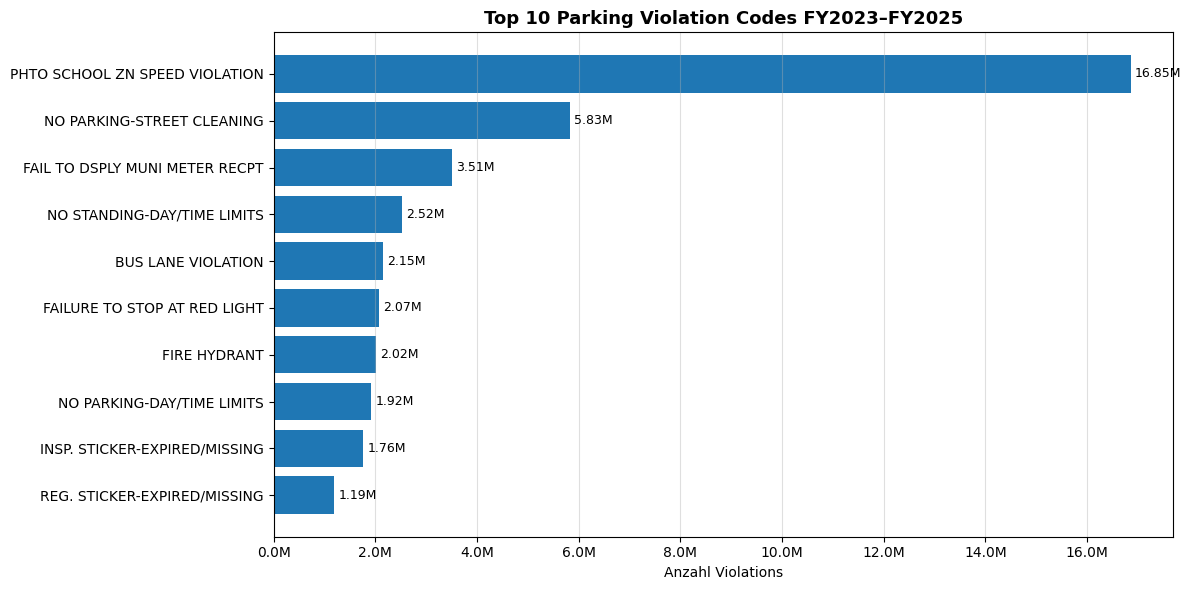

violation_code                    description    count
            36 PHTO SCHOOL ZN SPEED VIOLATION 16853673
            21     NO PARKING-STREET CLEANING  5828637
            38 FAIL TO DSPLY MUNI METER RECPT  3513550
            14    NO STANDING-DAY/TIME LIMITS  2516377
             5             BUS LANE VIOLATION  2150369
             7   FAILURE TO STOP AT RED LIGHT  2068262
            40                   FIRE HYDRANT  2016485
            20     NO PARKING-DAY/TIME LIMITS  1920515
            71  INSP. STICKER-EXPIRED/MISSING  1757404
            70   REG. STICKER-EXPIRED/MISSING  1191802


In [35]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

top10 = df.groupBy("violation_code") \
    .agg(
        f.count("*").alias("count"),
        f.first("violation_description_official").alias("description")
    ) \
    .orderBy(f.desc("count")) \
    .limit(10) \
    .toPandas()

top10_sorted = top10.sort_values("count")

fig, ax = plt.subplots(figsize=(12, 6))
bars = ax.barh(top10_sorted["description"], top10_sorted["count"], color="#1f77b4")

ax.set_title("Top 10 Parking Violation Codes FY2023–FY2025", fontsize=13, fontweight="bold")
ax.set_xlabel("Anzahl Violations")
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x/1e6:.1f}M"))
ax.grid(True, axis="x", alpha=0.4)

# Werte rechts neben den Balken
x_max = top10_sorted["count"].max()
for bar in bars:
    w = bar.get_width()
    ax.text(w + x_max * 0.005, bar.get_y() + bar.get_height()/2,
            f"{w/1e6:.2f}M", va="center", fontsize=9)

plt.tight_layout()
plt.savefig("analyse_top10_codes.png", dpi=150)
plt.show()

print(top10[["violation_code", "description", "count"]].to_string(index=False))

### Trend über die Jahre
Verändern sich die häufigsten Violations über FY2023, FY2024 und FY2025?

Top 5 Codes: ['36', '21', '38', '14', '5']


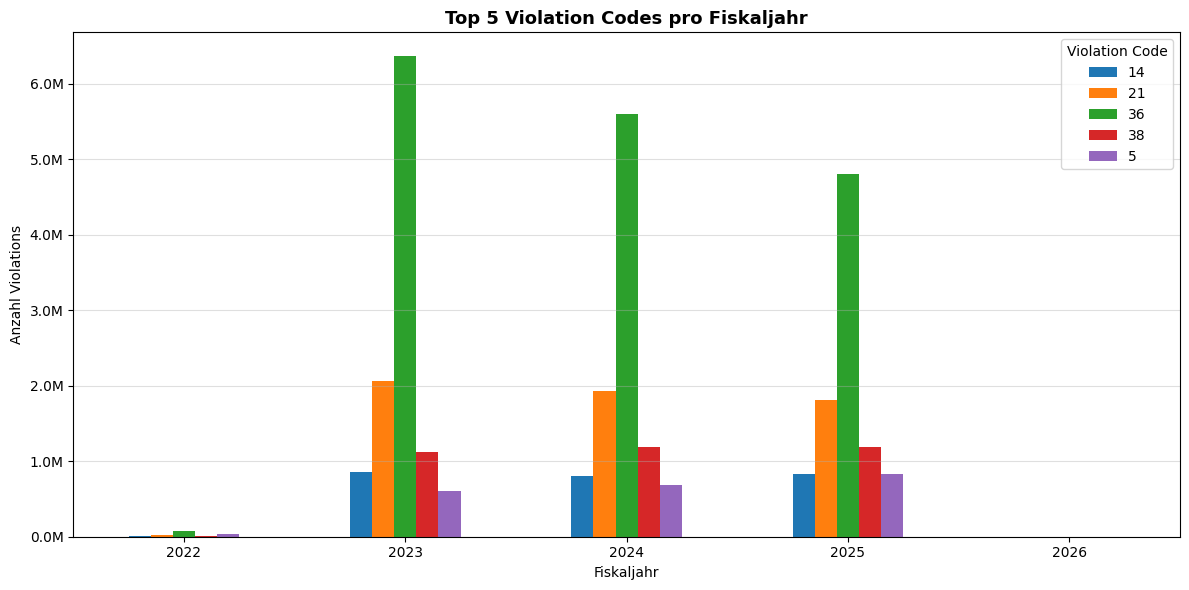

In [37]:
top5_codes = [
    row["violation_code"]
    for row in df.groupBy("violation_code")
               .count()
               .orderBy(f.desc("count"))
               .limit(5)
               .collect()
]
print("Top 5 Codes:", top5_codes)

yearly_trend = df.filter(f.col("violation_code").isin(top5_codes)) \
    .groupBy("fy", "violation_code") \
    .count() \
    .orderBy("violation_code", "fy") \
    .toPandas()

pivot_trend = yearly_trend.pivot(index="fy", columns="violation_code", values="count")

fig, ax = plt.subplots(figsize=(12, 6))
pivot_trend.plot(kind="bar", ax=ax)

ax.set_title("Top 5 Violation Codes pro Fiskaljahr", fontsize=13, fontweight="bold")
ax.set_xlabel("Fiskaljahr")
ax.set_ylabel("Anzahl Violations")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x/1e6:.1f}M"))
ax.grid(True, axis="y", alpha=0.4)
ax.legend(title="Violation Code")
plt.xticks(rotation=0)

plt.tight_layout()
plt.savefig("analyse_top5_trend.png", dpi=150)
plt.show()

### Detailzahlen Code 36
Um die Veränderung über die Jahre genau zu beziffern, schauen wir uns 
die absoluten Zahlen für den häufigsten Verstoss an.

In [38]:
%%time
yearly_counts_36 = df \
    .filter(f.col("violation_code") == "36") \
    .groupBy("fy") \
    .count() \
    .orderBy("fy") \
    .toPandas()

# Prozentuale Veränderung explizit berechnen
count_2023 = yearly_counts_36.loc[yearly_counts_36["fy"] == 2023, "count"].values[0]
count_2025 = yearly_counts_36.loc[yearly_counts_36["fy"] == 2025, "count"].values[0]
pct_change = (count_2025 - count_2023) / count_2023 * 100

print("Code 36 – Exceeding speed limit in school zone:")
print(yearly_counts_36.to_string(index=False))
print(f"\nVeränderung FY2023 → FY2025: {pct_change:+.1f}%")

[Stage 32:========================================>               (18 + 6) / 25]

Code 36 – Exceeding speed limit in school zone:
  fy   count
2022   82024
2023 6365887
2024 5604072
2025 4801690

Veränderung FY2023 → FY2025: -24.6%
CPU times: user 10.9 ms, sys: 4.42 ms, total: 15.4 ms
Wall time: 1.77 s


### Detailzahlen Top 5 Codes
Übersicht aller Top-5 Violation Codes mit exakten Zahlen pro Fiskaljahr.

In [39]:
summary = df \
    .filter(f.col("violation_code").isin(top5_codes)) \
    .groupBy("fy", "violation_code") \
    .agg(
        f.count("*").alias("count"),
        f.first("violation_description_official").alias("description")
    ) \
    .orderBy("violation_code", "fy") \
    .toPandas()

print(summary.to_string(index=False))

[Stage 40:=====================================================>  (24 + 1) / 25]

  fy violation_code   count                    description
2022             14   12138    NO STANDING-DAY/TIME LIMITS
2023             14  861859    NO STANDING-DAY/TIME LIMITS
2024             14  809003    NO STANDING-DAY/TIME LIMITS
2025             14  833244    NO STANDING-DAY/TIME LIMITS
2026             14     133    NO STANDING-DAY/TIME LIMITS
2022             21   20324     NO PARKING-STREET CLEANING
2023             21 2060275     NO PARKING-STREET CLEANING
2024             21 1933777     NO PARKING-STREET CLEANING
2025             21 1814241     NO PARKING-STREET CLEANING
2026             21      20     NO PARKING-STREET CLEANING
2022             36   82024 PHTO SCHOOL ZN SPEED VIOLATION
2023             36 6365887 PHTO SCHOOL ZN SPEED VIOLATION
2024             36 5604072 PHTO SCHOOL ZN SPEED VIOLATION
2025             36 4801690 PHTO SCHOOL ZN SPEED VIOLATION
2022             38   11652 FAIL TO DSPLY MUNI METER RECPT
2023             38 1128258 FAIL TO DSPLY MUNI METER REC

### Interpretation
- Code 36 (Schulzone Tempolimit) ist mit Abstand der häufigste Verstoss, 
  sinkt aber von 8 Mio. (FY2023) auf 4.9 Mio. (FY2025) — ein Rückgang von ~39%.
- Code 21 (Parkverbot Strassenreinigung) bleibt stabil auf Platz 2.
- Alle Top-5 Codes zeigen einen leichten Rückgang über die drei Jahre.
- Die Reihenfolge der häufigsten Violations bleibt über alle Jahre konstant.

### Fazit Analyse 1
Die Frage "Welche Violation-Typen kommen am häufigsten vor?" kann klar beantwortet werden:

Code 36 (Schulzone Tempolimit) dominiert mit grossem Abstand — dies ist womöglich auf
automatische Fotoblitzer in Schulzonen zurückzuführen. Bemerkenswert ist der 
kontinuierliche Rückgang über alle Top-Codes von FY2023 auf FY2025, was auf 
weniger Verstösse oder veränderte Enforcement-Strategien hindeuten könnte.

In [40]:
spark.stop()